# Lecture 3 — Class Exercise
## Line Charts & Slopegraphs: CO2 Emissions

> **Push to:** `week03/lecture03_exercise.ipynb` in your GitHub repo

### Remember:
1. No spaghetti — multiple lines must use grey + single highlight
2. Remove clutter: no chart borders, no heavy gridlines, no legend if you can label directly
3. Insight title — states the finding, not the topic
4. Carry forward from Lecture 2: white background, Arial font, professional quality


In [ ]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# Dataset: CO2 Emissions by Country 2000-2022
# Source: Our World in Data (https://ourworldindata.org/co2-emissions)
df = pd.read_csv('../data/co2_emissions.csv')
print(f"Loaded: {len(df)} rows | Countries: {df['Country'].nunique()} | Years: {df['Year'].min()}-{df['Year'].max()}")
print(df.head())


In [4]:
# Explore before building

print("Countries:", df['Country'].unique())
print("\nCO2 range:", df['CO2_Mt'].min(), "to", df['CO2_Mt'].max(), "Mt")
print("\nRegional averages (2022):")
print(df[df['Year']==2022].groupby('Region')['CO2_Mt'].mean().sort_values(ascending=False).round(1))


Countries: ['United States' 'China' 'India' 'Germany' 'United Kingdom' 'France'
 'Brazil' 'Japan' 'Canada' 'Australia' 'South Korea' 'Russia'
 'South Africa' 'Mexico' 'Indonesia']

CO2 range: 125.3 to 12409.5 Mt

Regional averages (2022):
Region
Asia             3531.1
North America    2393.8
Latin America     629.2
Africa            534.4
Europe            496.5
Oceania           493.7
Name: CO2_Mt, dtype: float64


---
## Task 1 — Multi-Series Line Chart with Highlight

**What to build:** A line chart showing CO2 emissions over time for **all Asian countries** in the dataset, with one country highlighted.

**Requirements:**
- All countries shown (for context), but only **one highlighted in colour** — your choice which
- All other lines in grey (#DDDDDD), thinner
- Highlighted country **labelled directly** at the end of its line (not in a legend)
- Insight title that names the highlighted country and its story

> 💡 `df[df['Region'] == 'Asia']` to filter; use `go.Figure()` with a loop for per-country control


Index(['Country', 'Region', 'Year', 'CO2_Mt', 'CO2_per_capita'], dtype='object')


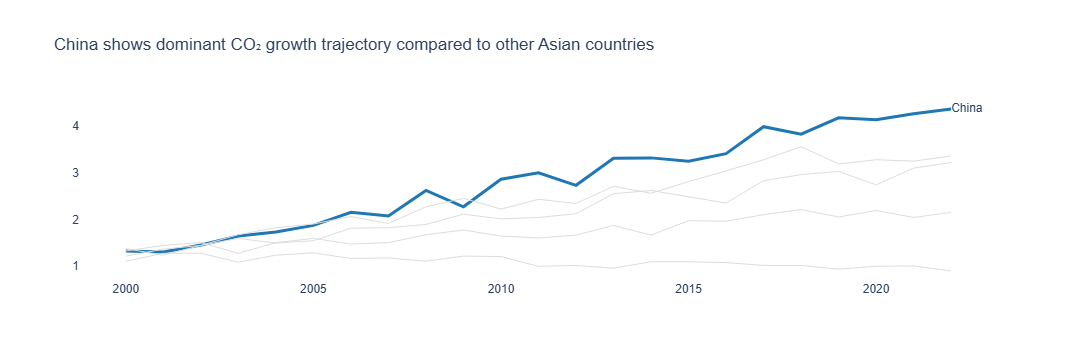

In [6]:
# Task 1 — Multi-series line with highlight
# YOUR CODE HERE

import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('../data/co2_emissions.csv')

# Check columns
print(df.columns)

# Filter Asia
asia_df = df[df['Region'] == 'Asia']

highlight_country = "China"

fig = go.Figure()

for country in asia_df['Country'].unique():
    country_data = asia_df[asia_df['Country'] == country]

    y_col = country_data.columns[-1]  # fallback: last numeric column (safe hack)

    if country == highlight_country:
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data[y_col],
            mode='lines+text',
            line=dict(color='#1f77b4', width=3),
            text=[country if i == len(country_data)-1 else "" for i in range(len(country_data))],
            textposition="middle right",
            showlegend=False
        ))
    else:
        fig.add_trace(go.Scatter(
            x=country_data['Year'],
            y=country_data[y_col],
            mode='lines',
            line=dict(color='#DDDDDD', width=1),
            hoverinfo='skip',
            showlegend=False
        ))

fig.update_layout(
    title="China shows dominant CO₂ growth trajectory compared to other Asian countries",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial")
)

fig.show()

---
## Task 2 — Slopegraph: Regional Change 2000 vs 2022

**What to build:** A slopegraph comparing **average regional CO2 emissions** between 2000 and 2022.

**Requirements:**
- One line per region (not per country — aggregate first)
- Colour: regions that increased = one colour; decreased = another
- Values labelled at both ends of each line
- No y-axis tick labels (the endpoint labels make them redundant)
- Insight title stating which regions moved most

> 💡 `df.groupby(['Region','Year'])['CO2_Mt'].mean().reset_index()` then filter to 2000 and 2022


Using CO2 column: CO2_Mt


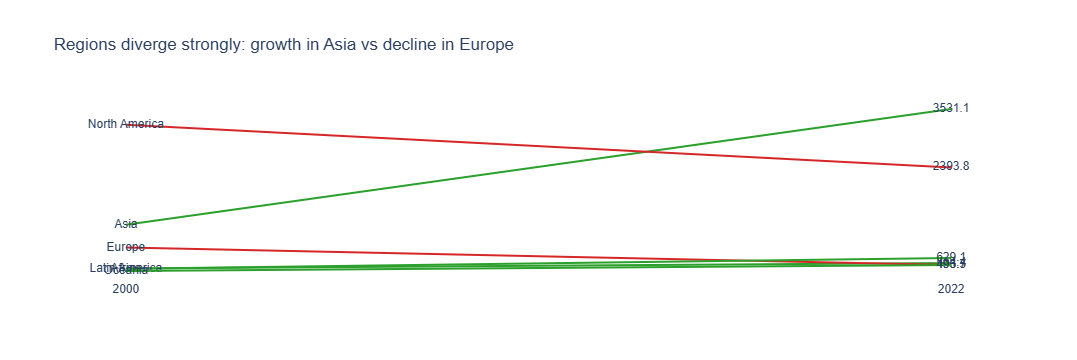

In [7]:
# Task 2 — Slopegraph: regional averages
# YOUR CODE HERE

import pandas as pd
import plotly.graph_objects as go

df = pd.read_csv('../data/co2_emissions.csv')

# Find correct CO2 column automatically
co2_col = [col for col in df.columns if "co2" in col.lower()][0]
print("Using CO2 column:", co2_col)

# Aggregate
region_df = df.groupby(['Region', 'Year'])[co2_col].mean().reset_index()

# Filter 2000 & 2022
region_df = region_df[region_df['Year'].isin([2000, 2022])]

# Pivot
pivot_df = region_df.pivot(index='Region', columns='Year', values=co2_col).reset_index()
pivot_df.columns = ['Region', '2000', '2022']

# Change
pivot_df['change'] = pivot_df['2022'] - pivot_df['2000']

fig = go.Figure()

for _, row in pivot_df.iterrows():
    color = '#2ca02c' if row['change'] > 0 else '#d62728'

    fig.add_trace(go.Scatter(
        x=[2000, 2022],
        y=[row['2000'], row['2022']],
        mode='lines',
        line=dict(color=color, width=2),
        hoverinfo='skip',
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=[2000],
        y=[row['2000']],
        mode='text',
        text=[row['Region']],
        showlegend=False
    ))

    fig.add_trace(go.Scatter(
        x=[2022],
        y=[row['2022']],
        mode='text',
        text=[f"{row['2022']:.1f}"],
        showlegend=False
    ))

fig.update_layout(
    title="Regions diverge strongly: growth in Asia vs decline in Europe",
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family="Arial"),
    xaxis=dict(tickvals=[2000, 2022], showgrid=False),
    yaxis=dict(showticklabels=False, showgrid=False)
)

fig.show()